# Final Project: Sleep Health & Lifestyle Dataset

### Objective: 

For this course project, I will build a sleep disorder classification model using the Sleep and Lifestyle Study Dataset from Kaggle,
training and comparing a Random Forest Classifier and an XGBoost model across the
dataset’s patient features. The goal is to predict whether a
patient has no sleep disorder, insomnia, or sleep apnea, evaluated using accuracy, F1-
score, ROC-AUC, and per-class precision-recall metrics. Both models will be audited using fairness metrics to ensure equal representation across demographics. 

## Basic Info & Cleaning 

In [24]:
import pandas as pd

df = pd.read_csv('./data/Sleep_health_and_lifestyle_dataset (Copy).csv')

print("Dataset Overview:")
print("=" * 50)
print(f"Total samples: {len(df)}\n")
print(df.info())

Dataset Overview:
Total samples: 374

<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    str    
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    str    
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    str    
 9   Blood Pressure           374 non-null    str    
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    str    
dtypes: float64(1), int64(7), str(5)
memory usage: 38.1 KB

In [60]:
# Checking for missing values
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing_values, 
                           'Percentage (%)': missing_percentage})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values('Percentage (%)', ascending=False)

print("Missing Values Analysis:")
display(missing_df)

Missing Values Analysis:


,Missing Values,Percentage (%)
Sleep Disorder,219,58.55615


In [62]:
# Handling missing values
# Fill missing values in Sleep Disorder with 'None'
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

df['Has_Sleep_Disorder'] = df['Sleep Disorder'].apply(lambda x: 0 if x == 'None' else 1)

# Convert categorical variables
# Extract systolic and diastolic BP
df[['Systolic', 'Diastolic']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)

# Encode gender
df['Gender_Encoded'] = df['Gender'].map({'Male': 0, 'Female': 1})

In [38]:
# Check for duplicates
print("-" * 50)
print(f"Duplicate entries: {df.duplicated().sum()}")

--------------------------------------------------
Duplicate entries: 0


In [ ]:
# Checking for missing values after modification
missing_values = df.isnull().sum()

display(missing_values)

Person ID                  0
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Blood Pressure             0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
Has_Sleep_Disorder         0
Systolic                   0
Diastolic                  0
Gender_Encoded             0
Age_Group                  0
dtype: int64

In [61]:
print(f'Disorder distribution: {df["Sleep Disorder"].value_counts().to_dict()}')

Disorder distribution: {'Sleep Apnea': 78, 'Insomnia': 77}


## Exploratory Data Analysis

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Set style for matplotlib
plt.style.use('default')
sns.set_palette("husl")

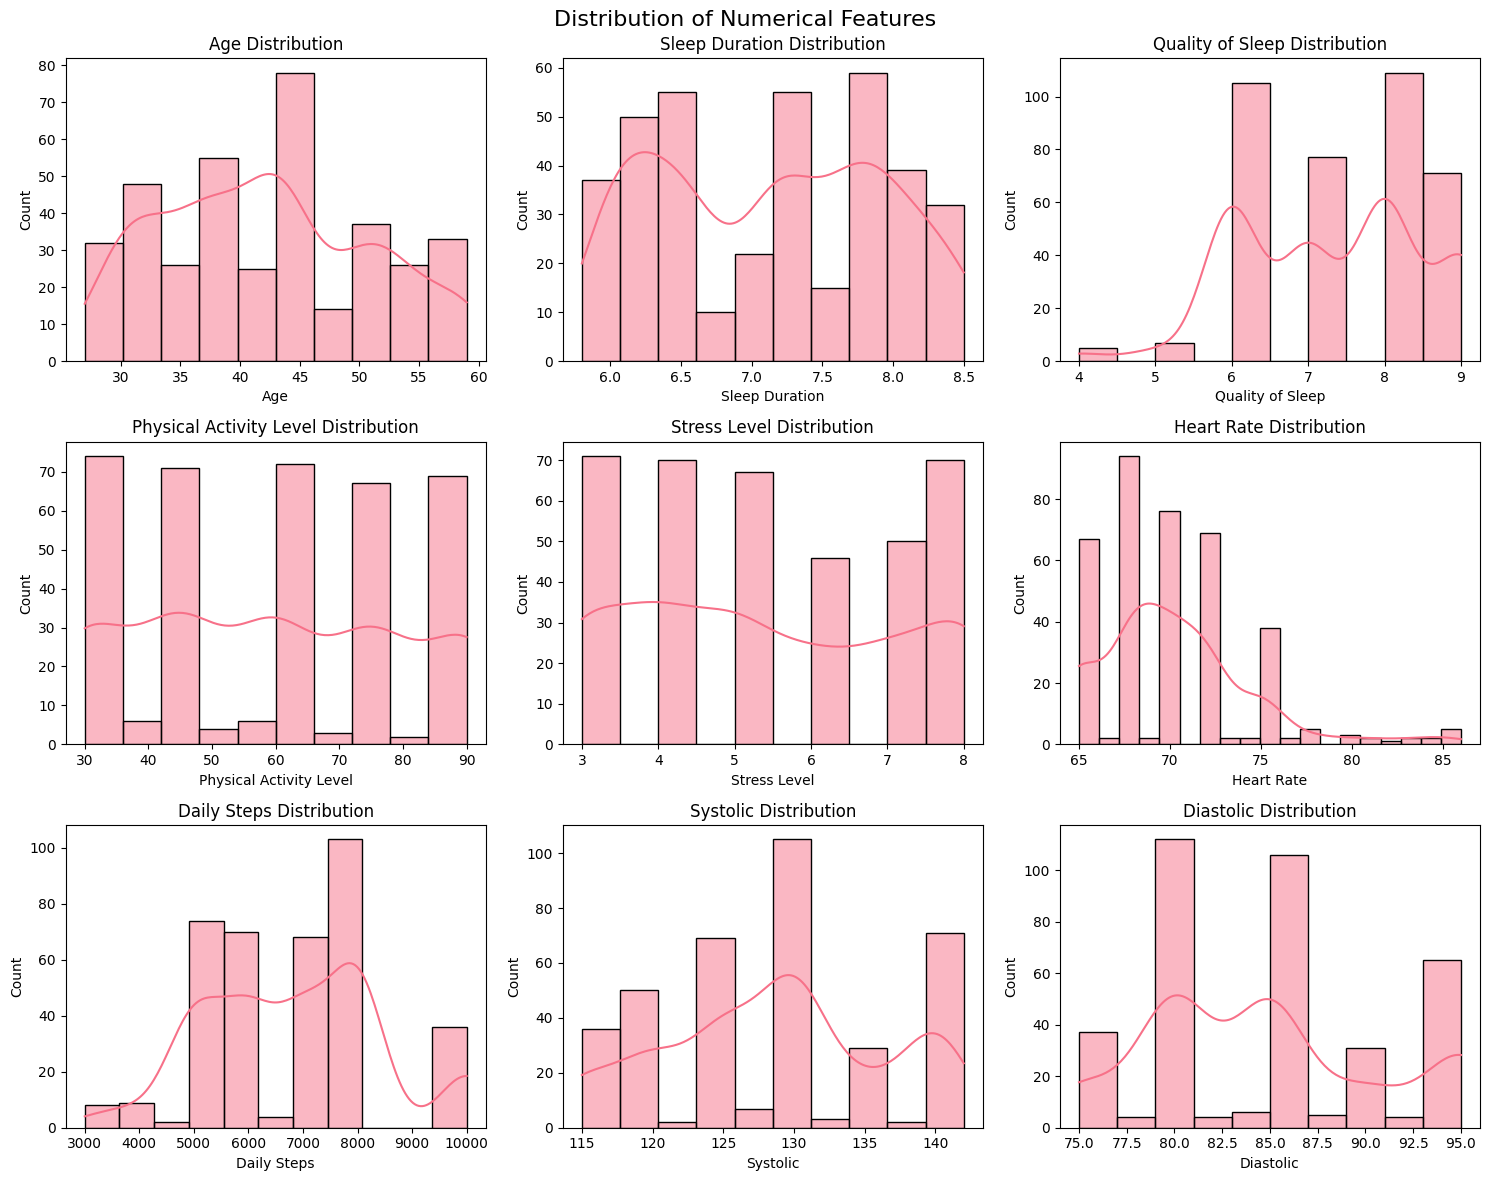

In [30]:
# Distribution of numerical features
numerical_cols = ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level',
                  'Stress Level', 'Heart Rate', 'Daily Steps', 'Systolic', 'Diastolic']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Distribution of Numerical Features', fontsize=16)

for i, col in enumerate(numerical_cols):
    ax = axes[i//3, i%3]
    sns.histplot(data=df, x=col, ax=ax, kde=True)
    ax.set_title(f'{col} Distribution')

plt.tight_layout()
plt.show()

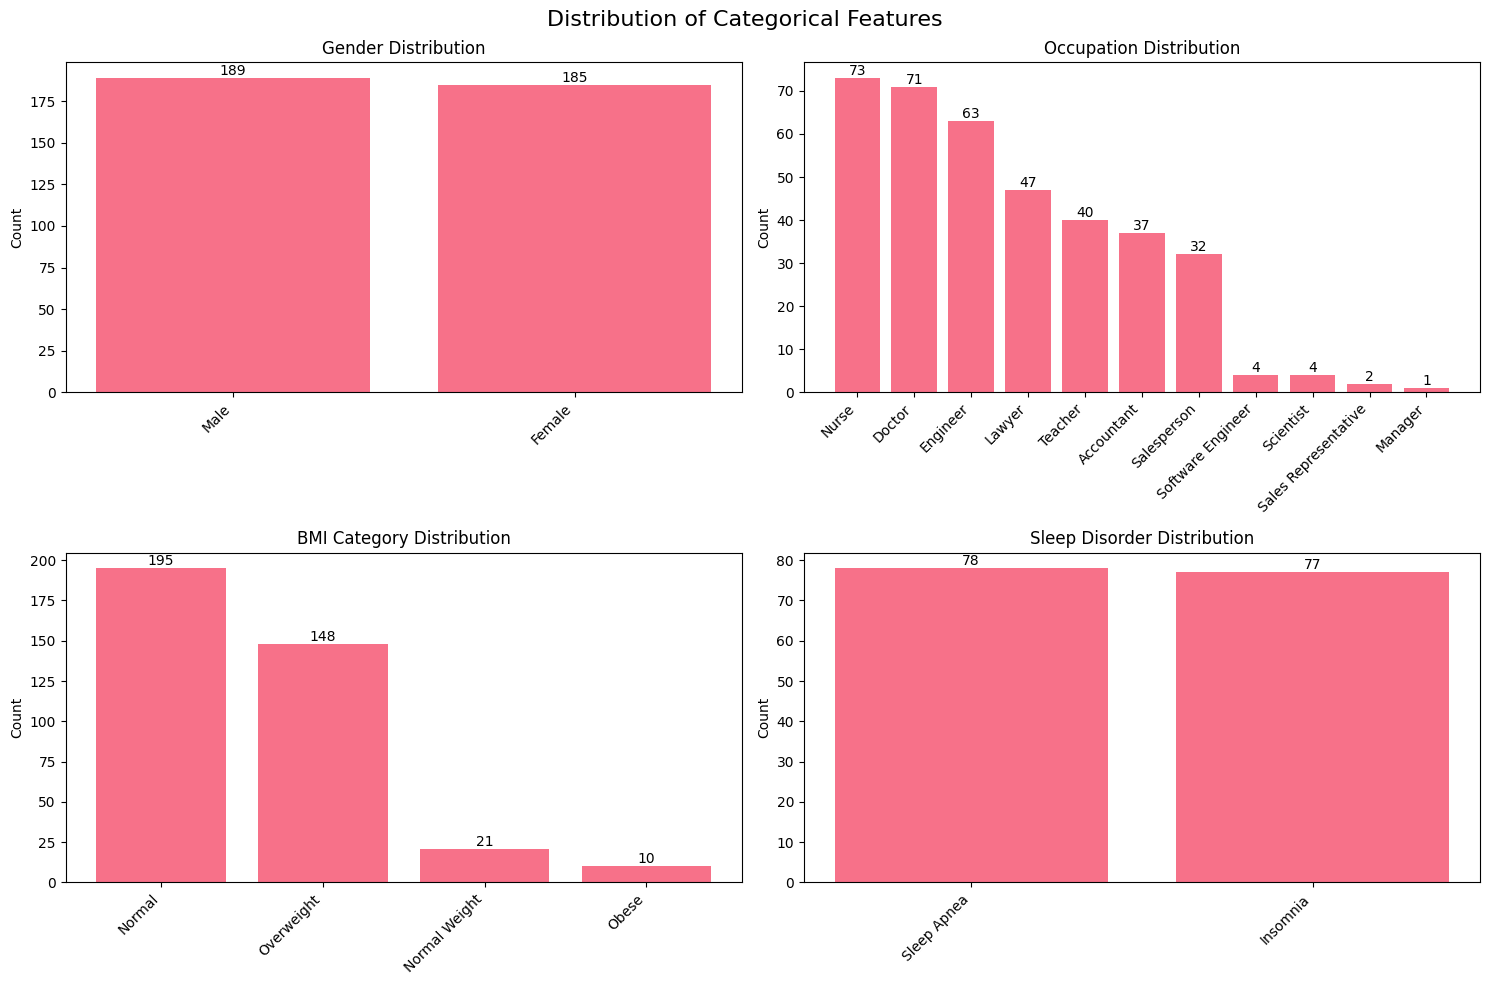

In [45]:
# Categorical features distribution
categorical_cols = ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribution of Categorical Features', fontsize=16)

for i, col in enumerate(categorical_cols):
    ax = axes[i//2, i%2]
    value_counts = df[col].value_counts()
    ax.bar(range(len(value_counts)), value_counts.values)
    ax.set_xticks(range(len(value_counts)))
    ax.set_xticklabels(value_counts.index, rotation=45, ha='right')
    ax.set_title(f'{col} Distribution')
    ax.set_ylabel('Count')

plt.tight_layout()

for i, col in enumerate(categorical_cols):
    ax = axes[i//2, i%2]
    for j, bar in enumerate(ax.patches):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=10)
plt.show()

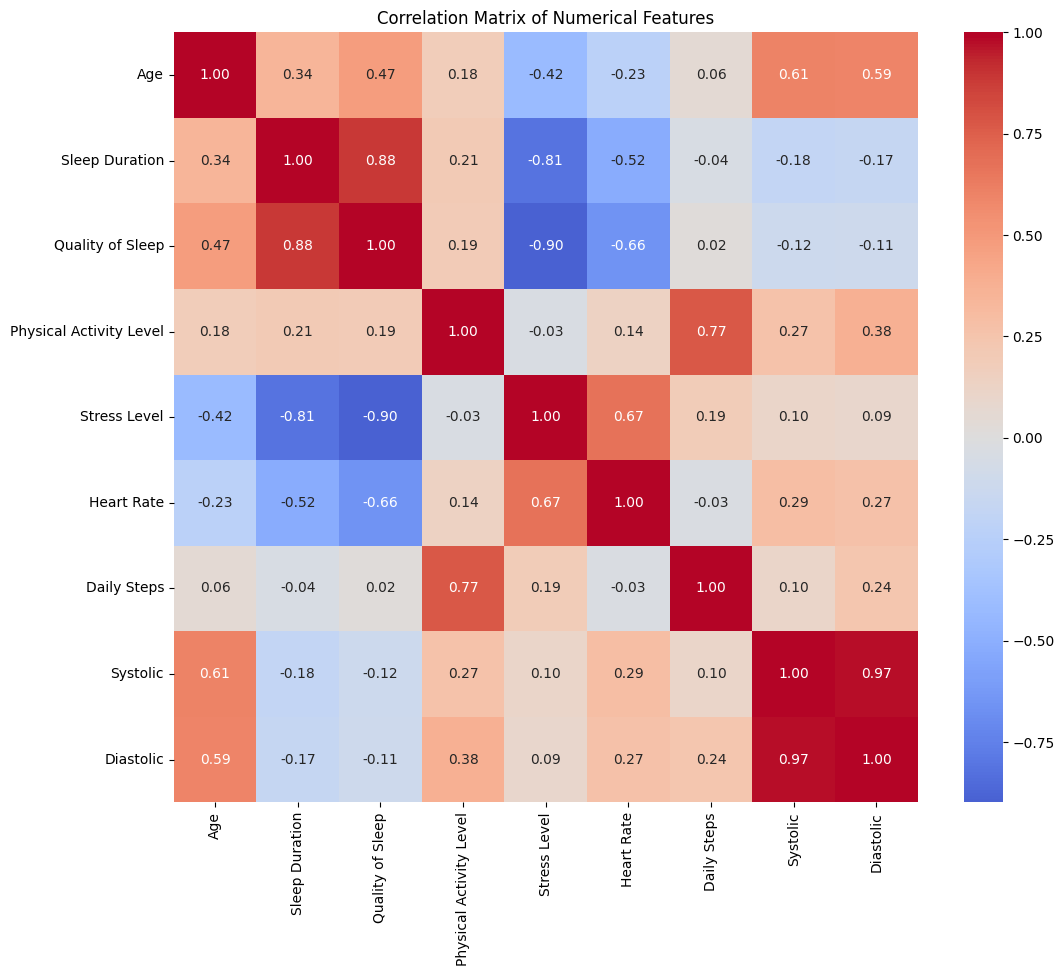

In [32]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

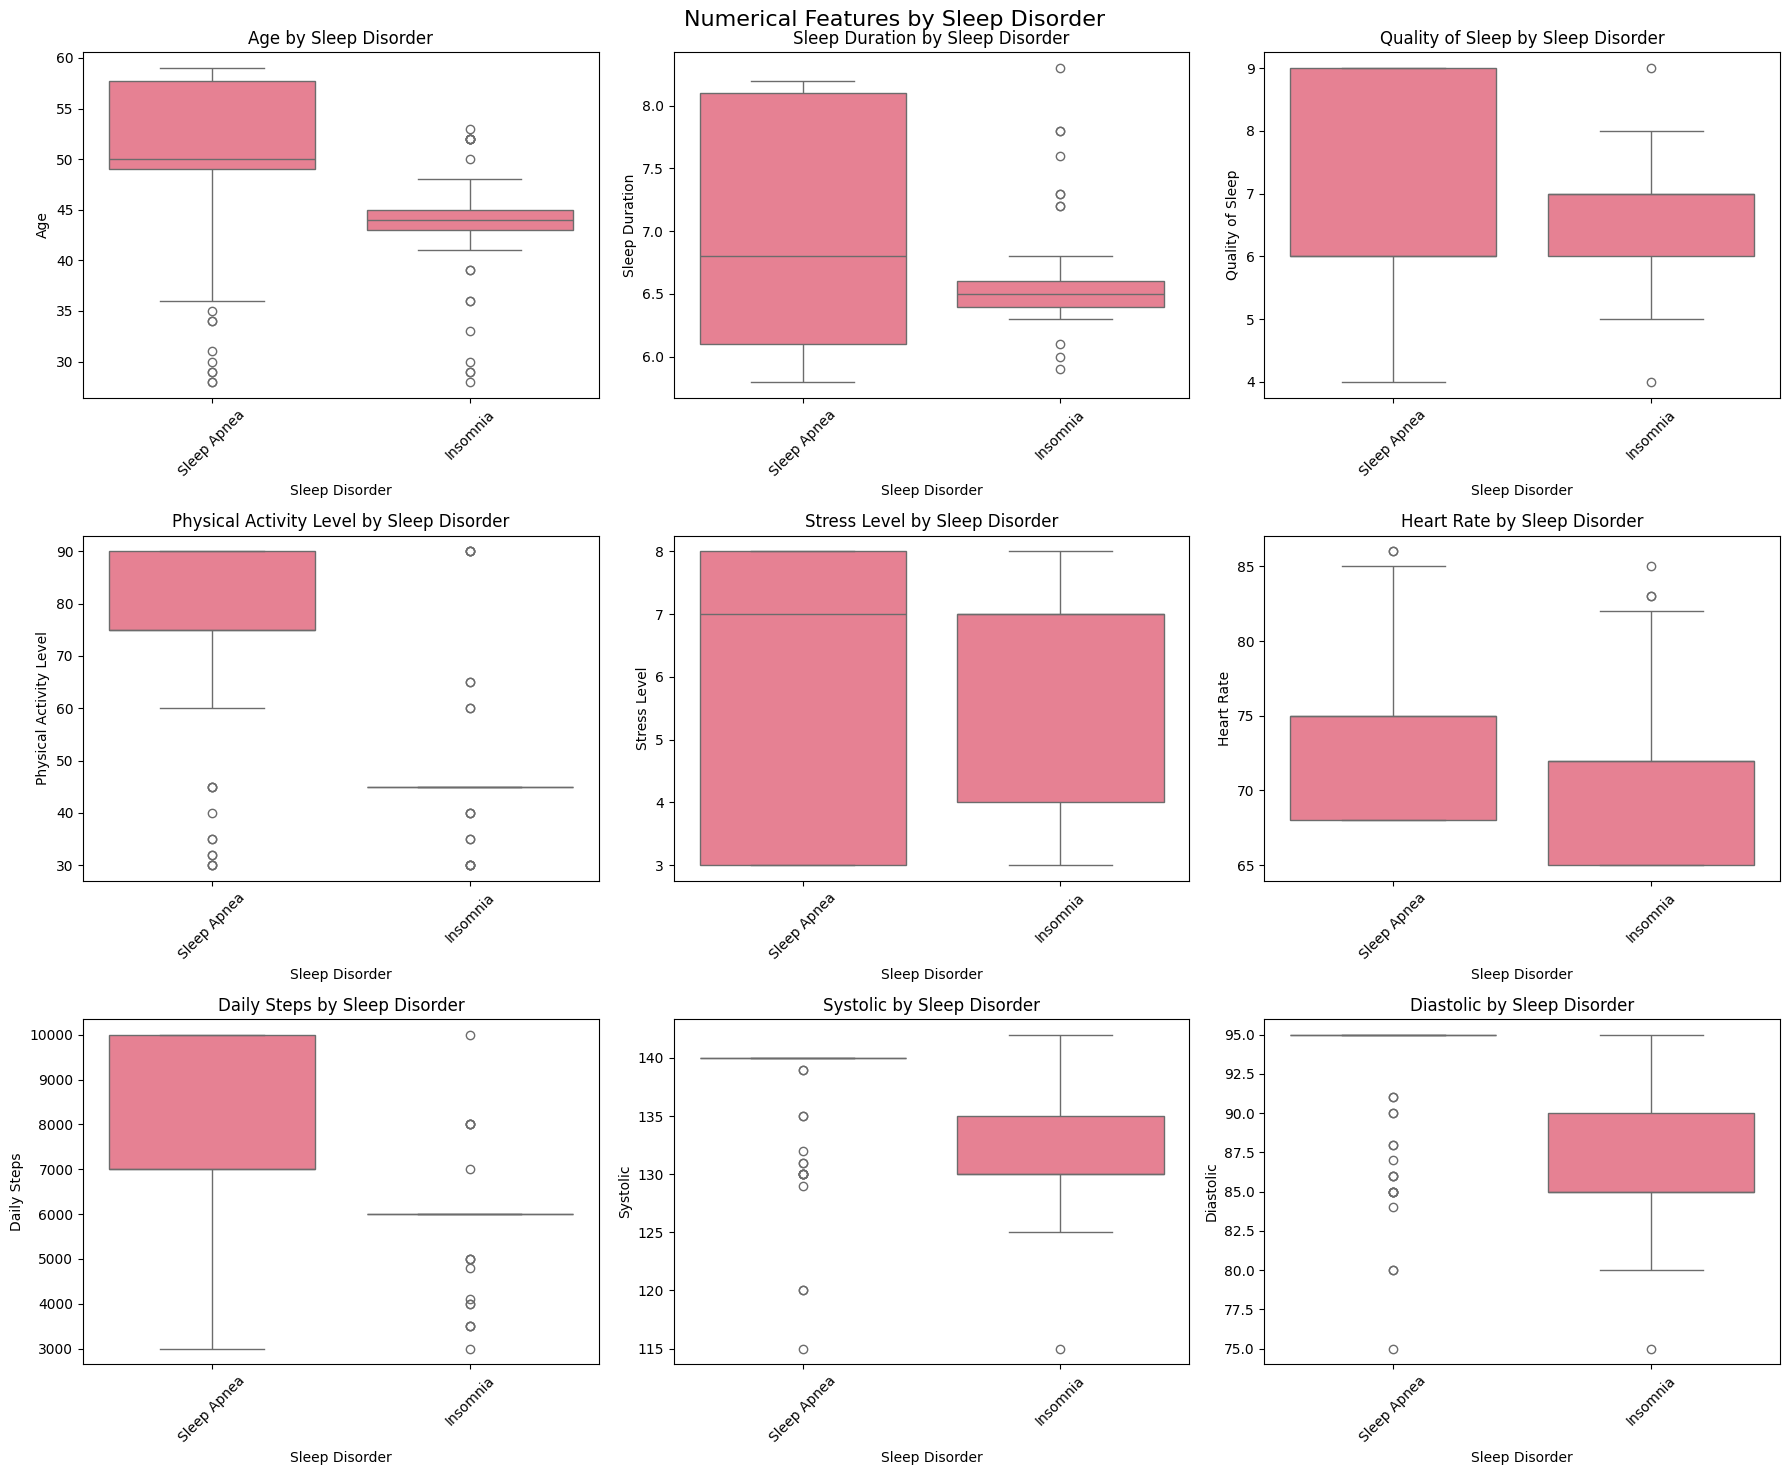

In [33]:
# Box plots of numerical features by Sleep Disorder
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Numerical Features by Sleep Disorder', fontsize=16)

for i, col in enumerate(numerical_cols):
    ax = axes[i//3, i%3]
    sns.boxplot(data=df, x='Sleep Disorder', y=col, ax=ax)
    ax.set_title(f'{col} by Sleep Disorder')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

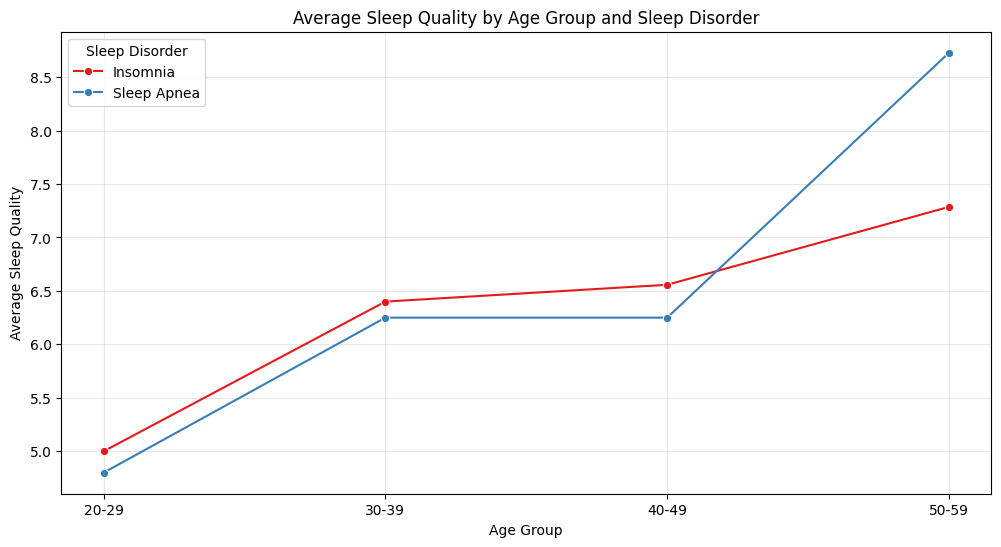

In [ ]:
# Line plot: Average Sleep Quality by Age Group and Sleep Disorder
df['Age_Group'] = pd.cut(df['Age'], bins=[20, 30, 40, 50, 60], labels=['20-29', '30-39', '40-49', '50-59'])

avg_quality_by_age_disorder = df.groupby(['Age_Group', 'Sleep Disorder'])['Quality of Sleep'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_quality_by_age_disorder, x='Age_Group', y='Quality of Sleep', hue='Sleep Disorder', marker='o', palette='Set1')
plt.title('Average Sleep Quality by Age Group and Sleep Disorder')
plt.xlabel('Age Group')
plt.ylabel('Average Sleep Quality')
plt.legend(title='Sleep Disorder')
plt.grid(True, alpha=0.3)
plt.show()

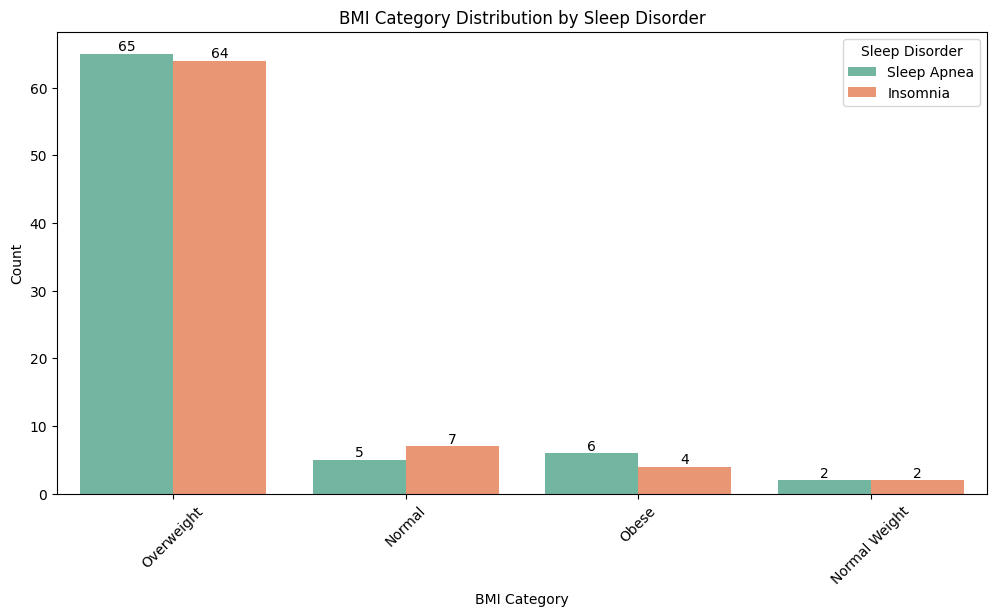

In [58]:
# BMI Category distribution by Sleep Disorder
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df, x='BMI Category', hue='Sleep Disorder', palette='Set2')
plt.title('BMI Category Distribution by Sleep Disorder')
plt.xlabel('BMI Category')
plt.ylabel('Count')
plt.legend(title='Sleep Disorder')
plt.xticks(rotation=45)

# Add count labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10)

plt.show()